In [1]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

## 1) Import methods

In [37]:
#!pip install timm torch torchvision seaborn scikit-learn
# Imports


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import random
import os
import copy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import timm

from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score
)
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import label_binarize


from transformers import AutoModel
from torchvision import transforms
import torchvision.transforms as T
from sklearn.metrics import classification_report
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc as sklearn_auc 


plt.style.use('default')
sns.set_palette("husl")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch: {torch.__version__}, timm: {timm.__version__}, Device: {device}")



PyTorch: 2.10.0+cu128, timm: 1.0.25, Device: cuda


## 2) Load dataset

In [3]:
from pathlib import Path

# folder where this script is located
#PROJECT_ROOT = Path().resolve()  # current working directory
DATA_DIR = Path('/kaggle/input/datasets/archiesrikumar/bec-dataset/data')
DATA_FILES_DIR = DATA_DIR / 'data_files'
LABELS_FILE = DATA_DIR / 'data_info' / 'data_info' /'data_roster.csv'

print(DATA_FILES_DIR.exists())  # should be True
print(LABELS_FILE.exists())     # should be True
labels_df = pd.read_csv(LABELS_FILE, index_col=0)

def load_bec_dataset(data_dir, labels_df, max_samples=None, shuffle_seed=42):
    class_dirs = sorted(
        [d for d in data_dir.glob('class-*') if d.is_dir()],
        key=lambda p: int(p.name.split('-')[-1]) if p.name.split('-')[-1].isdigit() else 0
    )
    all_files = []
    for cd in class_dirs:
        all_files.extend(sorted(cd.glob('*.npy')))
    
    if shuffle_seed is not None:
        random.seed(shuffle_seed)
        random.shuffle(all_files)
    if max_samples:
        all_files = all_files[:max_samples]

    images, labels_list, positions_list = [], [], []
    for fp in tqdm(all_files, desc="Loading"):
        try:
            d = np.load(fp, allow_pickle=True).item()
            img = d['masked_data'].reshape(132, 164, 1)
            rel = '/data/' + '/'.join(fp.parts[-3:])
            if rel in labels_df.index:
                row = labels_df.loc[rel]
                label = int(row['label_v3'])
                pos_str = row['excitation_position']
                pos = []
                if not pd.isna(pos_str) and pos_str != '':
                    try:
                        pos = eval(pos_str) if isinstance(pos_str, str) else []
                        if not isinstance(pos, list):
                            pos = [pos] if pos else []
                    except:
                        pos = []
                images.append(img)
                labels_list.append(label)
                positions_list.append(pos)
        except Exception as e:
            print(f"Error: {fp}: {e}")

    images = np.array(images, dtype=np.float32)
    labels_arr = np.array(labels_list, dtype=np.int32)
    print(f"Loaded {len(images)} images {images.shape}")
    return images, labels_arr, positions_list

images, labels, positions = load_bec_dataset(DATA_FILES_DIR, labels_df, max_samples=None) #max_samples is None for full data set

True
True


Loading: 100%|██████████| 16478/16478 [00:56<00:00, 293.10it/s]


Loaded 16478 images (16478, 132, 164, 1)


##  3) Filter and split the data

In [4]:
valid = labels < 8
images_f = images[valid]
labels_f = labels[valid].copy()
positions_f = [positions[i] for i in range(len(positions)) if valid[i]]

labels_f[labels_f >= 2] = 2
print(f"Filtered: {len(images_f)}, distribution: {np.bincount(labels_f)}")

X_train, X_test, y_train, y_test, pos_train, pos_test = train_test_split(
    images_f, labels_f, positions_f,
    test_size=0.2, random_state=42, stratify=labels_f
)
print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print(f"Train dist: {np.bincount(y_train)}, Test dist: {np.bincount(y_test)}")


Filtered: 5378, distribution: [1130 3212 1036]
Train: 4302, Test: 1076
Train dist: [ 904 2569  829], Test dist: [226 643 207]


## 4) Define dataset, model and training method

In [36]:
class BECDataset(Dataset):
    def __init__(self, images, labels, transform=None, augment=False):
        self.images = images
        self.labels = labels
        self.transform = transform
        self.augment = augment

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        
        img = np.squeeze(self.images[idx]).astype(np.float32)

        if img.max() > 1.0:
            img = img / 255.0

        img_3ch = np.stack([img, img, img], axis=0) 

        img_tensor = torch.from_numpy(img_3ch)

        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        img_tensor = (img_tensor - mean) / std

        if self.transform:
            img_tensor = self.transform(img_tensor)
            
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return img_tensor, label




def create_Dinov2(num_classes, pretrained=True, freeze_backbone=True):
    """
    Creates a DINOv2-based classifier for BEC soliton images.
    
    Args:
        num_classes (int): Number of soliton categories.
        pretrained (bool): Whether to load ImageNet-pretrained weights.
        freeze_backbone (bool): If True, only the classification head trains.
    """
    
    # 1. Load the backbone (Small version: 384-dim output)

    backbone = AutoModel.from_pretrained('facebook/dinov2-small')
    
    # 2. Freeze the backbone parameters
    if freeze_backbone:
        for param in backbone.parameters():
            param.requires_grad = False
            
    # 3. Define the classification head

    classifier_head = nn.Sequential(
        nn.Linear(384, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes)
    )
    
    # 4. Attach the head to the backbone
    class DINOv2Classifier(nn.Module):
        def __init__(self, backbone, head):
            super().__init__()
            self.backbone = backbone
            self.head = head
            
        def forward(self, x):
            # Extract features (the CLS token / pooler_output)
            features = self.backbone(x).pooler_output
            return self.head(features)

    model = DINOv2Classifier(backbone, classifier_head)
    
    # Move to GPU if available
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    
    print(f"Model created on {device}. Backbone frozen: {freeze_backbone}")
    return model


def unfreeze_model(model, backbone_lr=1e-6, head_lr=1e-4): # Lower backbone LR
    for p in model.parameters():
        p.requires_grad = True

    backbone_params = []
    head_params = []

    for name, p in model.named_parameters():
        # Change 'classifier' to 'head' to match our DINOv2 model
        if 'head' in name: 
            head_params.append(p)
        else:
            backbone_params.append(p)

    print(f"Unfrozen: {len(backbone_params)} backbone tensors, {len(head_params)} head tensors")

    return [
        {'params': backbone_params, 'lr': backbone_lr},
        {'params': head_params, 'lr': head_lr},
    ]



def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct += (out.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def eval_model(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels, all_probs = [], [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        out = model(imgs)
        loss = criterion(out, labels)
        probs = torch.softmax(out, dim=1)
        total_loss += loss.item() * imgs.size(0)
        correct += (out.argmax(1) == labels).sum().item()
        total += labels.size(0)
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
    return (total_loss / total, correct / total,
            np.array(all_preds), np.array(all_labels), np.array(all_probs))


def two_phase_train(model, train_loader, val_loader, device,
                    phase1_epochs=50, phase2_epochs=50,
                    phase1_lr=1e-3, phase2_backbone_lr=3e-6, phase2_head_lr=5e-4):
    """
    Back to the 0.8548 settings, only adapter_dim changed.
    """
    # Class weights
    all_labels = []
    for _, labels in train_loader:
        all_labels.extend(labels.numpy())
    counts = np.bincount(all_labels)
    weights = 1.0 / np.sqrt(counts)
    weights = weights / weights.sum() * len(counts)
    criterion = nn.CrossEntropyLoss(
    weight=torch.FloatTensor(weights).to(device),
    label_smoothing=0.1
)

    history = {'phase': [], 'epoch': [], 'train_loss': [], 'train_acc': [],
               'val_loss': [], 'val_acc': []}
    best_val_acc = 0
    best_state = None
    patience_counter = 0
    PATIENCE = 10

    # ---- Phase 1 ----MMMM
    print("Phase 1: Head + adapter only")
    opt = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=phase1_lr, weight_decay=1e-4
    )
    sched1 = optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=phase1_epochs, eta_min=phase1_lr * 0.01
    )

    for epoch in range(phase1_epochs):
        tl, ta = train_epoch(model, train_loader, criterion, opt, device)
        vl, va, _, _, _ = eval_model(model, val_loader, criterion, device)
        sched1.step()

        history['phase'].append(1)
        history['epoch'].append(epoch)
        history['train_loss'].append(tl)
        history['train_acc'].append(ta)
        history['val_loss'].append(vl)
        history['val_acc'].append(va)

        if va > best_val_acc:
            best_val_acc = va
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= PATIENCE:
            print(f"  Early stopping at epoch {epoch+1}")
            break

        if (epoch + 1) % 5 == 0:
            print(f"  {epoch+1}/{phase2_epochs} | "
                  f"train={ta:.4f} val={va:.4f} | "
                  f"backbone_lr={opt.param_groups[0]['lr']:.2e}")

    # ---- Phase 2 ----
    print(f"\nPhase 2: Full fine-tuning")
    model.load_state_dict(best_state)
    param_groups = unfreeze_model(model, phase2_backbone_lr, phase2_head_lr)
    opt = optim.AdamW(param_groups, weight_decay=1e-4)
    sched2 = optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=phase2_epochs, eta_min=phase2_backbone_lr * 0.01
    )
    patience_counter = 0

    for epoch in range(phase2_epochs):
        tl, ta = train_epoch(model, train_loader, criterion, opt, device)
        vl, va, _, _, _ = eval_model(model, val_loader, criterion, device)
        sched2.step()

        history['phase'].append(2)
        history['epoch'].append(phase1_epochs + epoch)
        history['train_loss'].append(tl)
        history['train_acc'].append(ta)
        history['val_loss'].append(vl)
        history['val_acc'].append(va)

        if va > best_val_acc:
            best_val_acc = va
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= PATIENCE:
            print(f"  Early stopping at epoch {epoch+1}")
            break

        if (epoch + 1) % 5 == 0:
            print(f"  {epoch+1}/{phase2_epochs} | "
                  f"train={ta:.4f} val={va:.4f} | "
                  f"backbone_lr={opt.param_groups[0]['lr']:.2e}")

    model.load_state_dict(best_state)
    print(f"\nBest val accuracy: {best_val_acc:.4f}")
    return history


## 5) Baseline

In [10]:
print("STEP 1: Baseline — DINOv2-Small (Frozen Backbone)")


num_classes = 3 
model = create_Dinov2(num_classes).to(device)
dinov2_transforms = T.Resize((224, 224))


train_ds = BECDataset(X_train, y_train, transform=dinov2_transforms)
test_ds = BECDataset(X_test, y_test, transform=dinov2_transforms)


train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)


history = two_phase_train(model, train_loader, test_loader, device)


criterion = nn.CrossEntropyLoss()
_, acc, y_pred, y_true, y_probs = eval_model(model, test_loader, criterion, device)

print(f"\nDINOv2 Baseline test accuracy: {acc:.4f}")
print(classification_report(y_true, y_pred, digits=4,
      target_names=['No soliton', 'Single', 'Other']))

torch.save(model.state_dict(), 'dinov2_soliton_baseline.pth')
print("Saved baseline weights")


STEP 1: Baseline — DINOv2-Small (Frozen Backbone)


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Model created on cuda. Backbone frozen: True
Phase 1: Head + adapter only
  5/50 | train=0.8480 val=0.8820 | backbone_lr=9.76e-04
  10/50 | train=0.8566 val=0.8959 | backbone_lr=9.05e-04
  15/50 | train=0.8647 val=0.8643 | backbone_lr=7.96e-04
  20/50 | train=0.8740 val=0.8922 | backbone_lr=6.58e-04
  25/50 | train=0.8766 val=0.9033 | backbone_lr=5.05e-04
  Early stopping at epoch 29

Phase 2: Full fine-tuning
Unfrozen: 223 backbone tensors, 4 head tensors
  5/50 | train=0.9184 val=0.9368 | backbone_lr=2.93e-06
  10/50 | train=0.9393 val=0.9526 | backbone_lr=2.72e-06
  15/50 | train=0.9586 val=0.9377 | backbone_lr=2.39e-06
  20/50 | train=0.9689 val=0.9433 | backbone_lr=1.97e-06
  25/50 | train=0.9763 val=0.9703 | backbone_lr=1.51e-06
  30/50 | train=0.9909 val=0.9610 | backbone_lr=1.06e-06
  35/50 | train=0.9960 val=0.9693 | backbone_lr=6.42e-07
  40/50 | train=0.9986 val=0.9721 | backbone_lr=3.14e-07
  45/50 | train=0.9993 val=0.9600 | backbone_lr=1.03e-07
  Early stopping at epoch 5

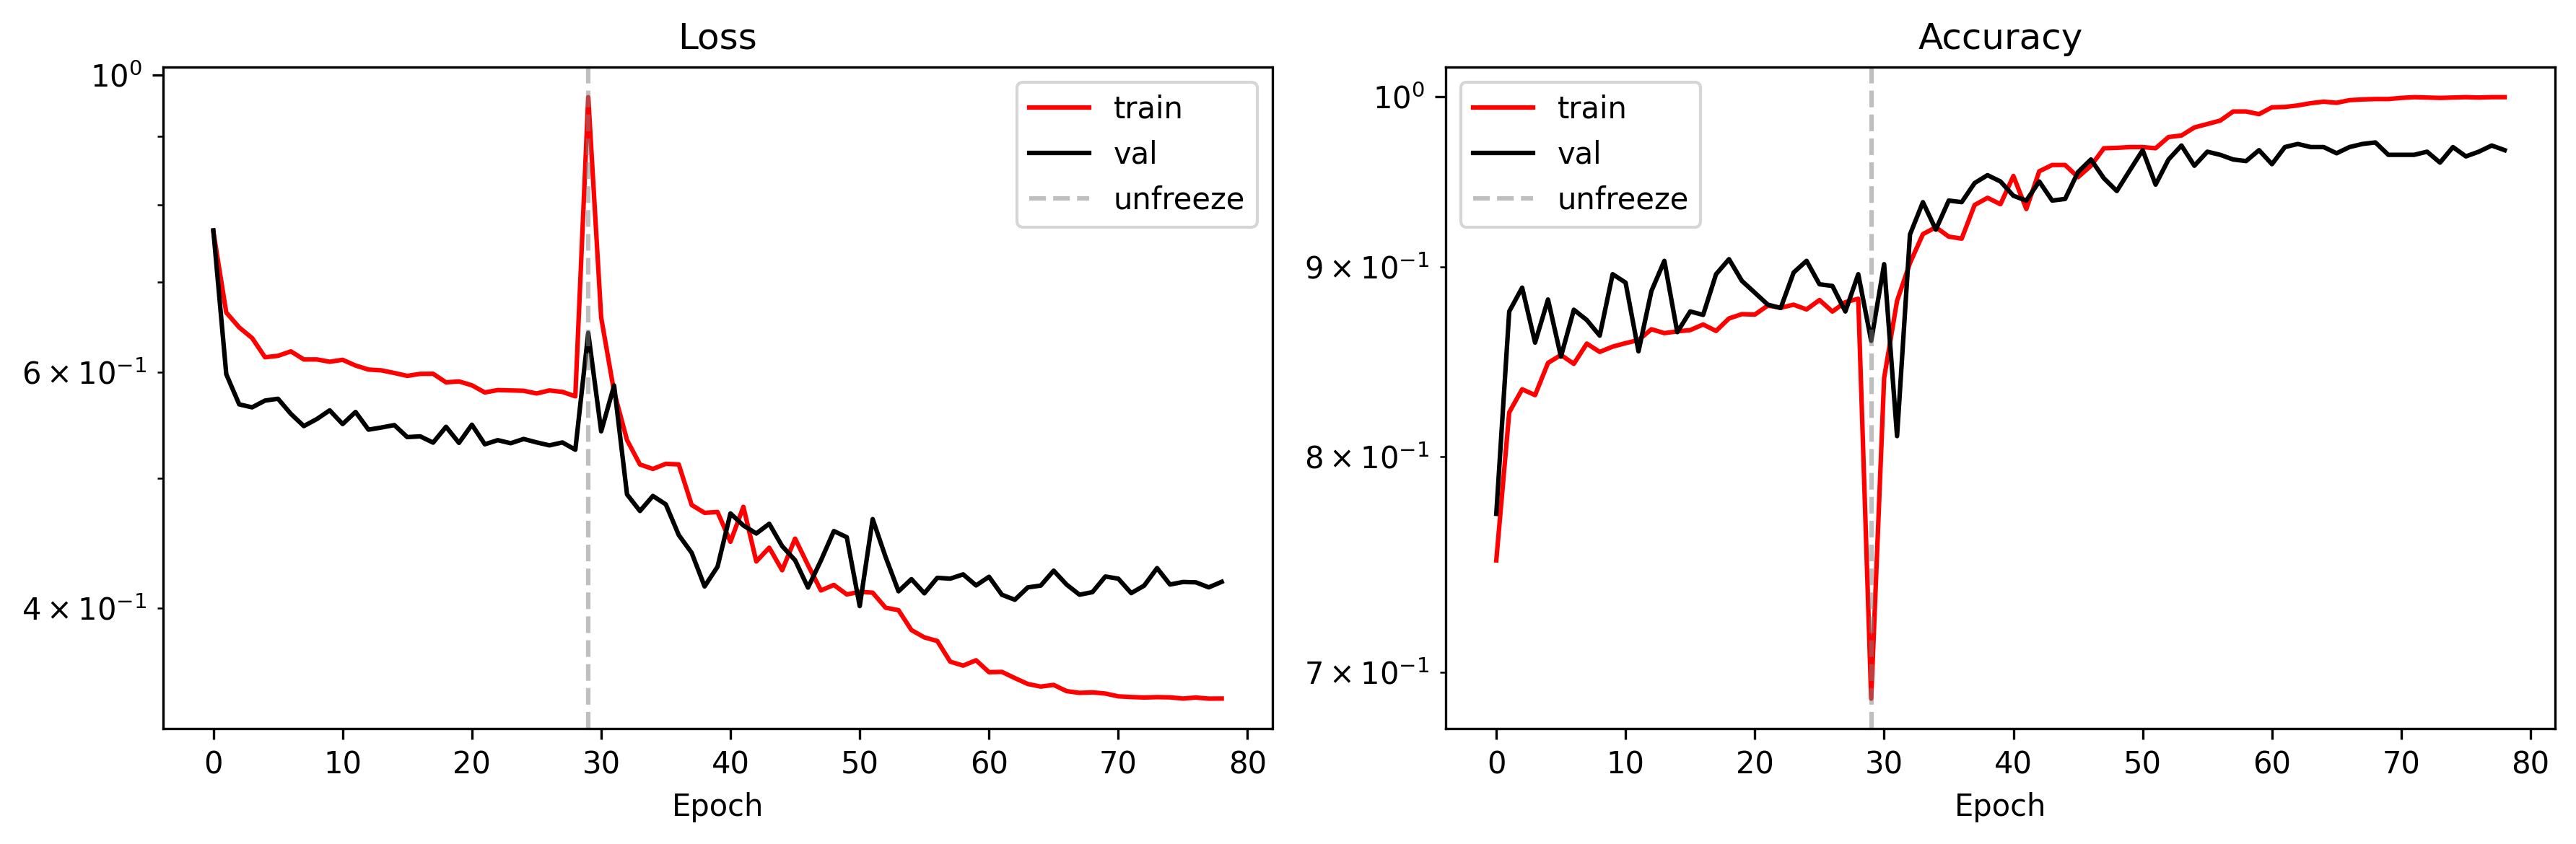

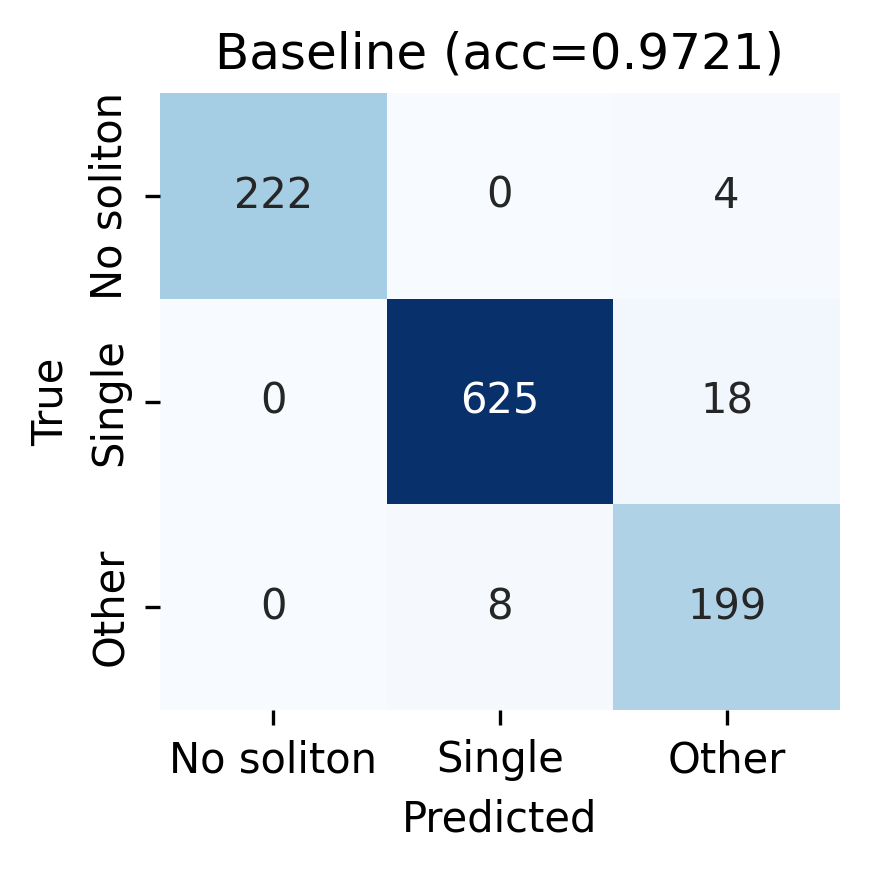

In [53]:
# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=300)
phase1_end = sum(1 for p in history['phase'] if p == 1)
for ax, metric, title in zip(axes, ['loss', 'acc'], ['Loss', 'Accuracy']):
    
    ax.set_yscale('log')
    ax.plot(history[f'train_{metric}'], label='train', color='red')
    ax.plot(history[f'val_{metric}'], label='val', color = 'black')
    ax.axvline(x=phase1_end, color='gray', ls='--', alpha=0.5, label='unfreeze')
    ax.set_xlabel('Epoch')
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.savefig("Loss and accuracy training curves-DINOv2.png")
plt.show()


cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(3, 3),dpi=300)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No soliton', 'Single', 'Other'],
            yticklabels=['No soliton', 'Single', 'Other'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Baseline (acc={acc:.4f})')
plt.tight_layout()
plt.savefig("Baseline confusion matrix-DINOv2.png")
plt.show()



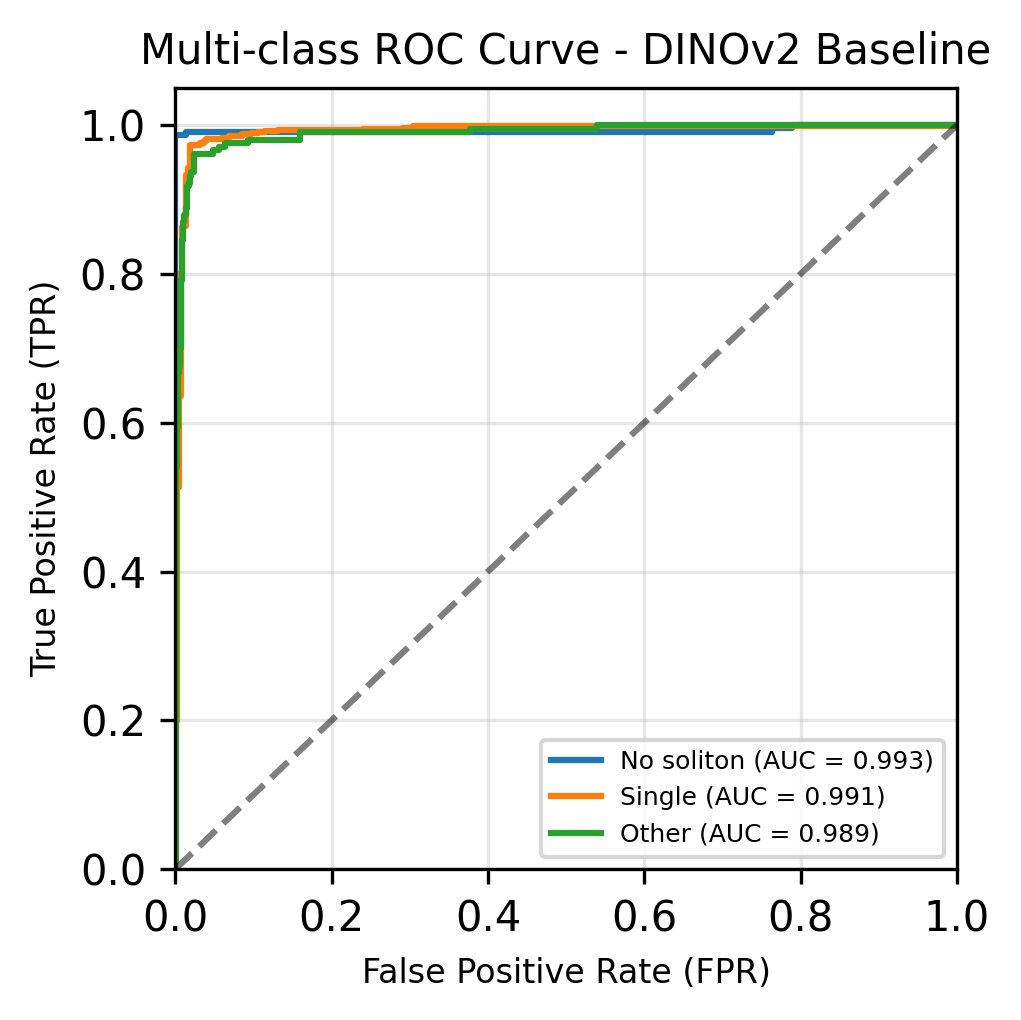

In [59]:
class_names = ['No soliton', 'Single', 'Other']
n_classes = len(class_names)
y_true_bin = label_binarize(y_true, classes=[0, 1, 2])
fpr = dict()
tpr = dict()
roc_auc_dict = dict() 
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc_dict[i] = sklearn_auc(fpr[i], tpr[i])


plt.figure(figsize=(3.5, 3.5), dpi=300)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] 

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color,
             label=f'{class_names[i]} (AUC = {roc_auc_dict[i]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=8)
plt.ylabel('True Positive Rate (TPR)', fontsize=8)
plt.title('Multi-class ROC Curve - DINOv2 Baseline', fontsize=10)
plt.legend(loc="lower right", fontsize=6)
plt.grid(alpha=0.3)
plt.tight_layout()
fig.savefig('Baseline ROC-DINOv2.jpg')
plt.show()


## 6) 5-fold cross-validation

In [17]:
print("=" * 60)
print("STEP 2: 5-Fold CV — Dinov2")
print("=" * 60)

N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

fold_models = []
fold_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    print(f"\n--- Fold {fold}/{N_FOLDS} ---")

    X_f_tr, y_f_tr = X_train[train_idx], y_train[train_idx]
    X_f_va, y_f_va = X_train[val_idx], y_train[val_idx]

    f_tr_loader = DataLoader(
        BECDataset(X_f_tr, y_f_tr, augment=True),
        batch_size=32, shuffle=True, num_workers=2
    )
    f_va_loader = DataLoader(
        BECDataset(X_f_va, y_f_va, augment=False),
        batch_size=32, shuffle=False, num_workers=2
    )

    fold_model = create_Dinov2(
        num_classes=3,
        freeze_backbone=True
    ).to(device)

    fold_history = two_phase_train(
        fold_model, f_tr_loader, f_va_loader, device
    )

    _, fold_acc, fold_preds, fold_labels, fold_probs = eval_model(
        fold_model, f_va_loader, criterion, device
    )

    fold_models.append(fold_model)
    fold_results.append({
        'fold': fold,
        'val_acc': fold_acc,
        'history': fold_history,
    })
    print(f"Fold {fold} val accuracy: {fold_acc:.4f}")

accs = [r['val_acc'] for r in fold_results]
print(f"\n{'='*60}")
print(f"CV Results: {[f'{a:.4f}' for a in accs]}")
print(f"Mean: {np.mean(accs):.4f} ± {np.std(accs):.4f}")
print(f"Baseline was: {acc:.4f}")
print(f"Difference: {np.mean(accs) - acc:+.4f}")

STEP 2: 5-Fold CV — Dinov2

--- Fold 1/5 ---


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Model created on cuda. Backbone frozen: True
Phase 1: Head + adapter only
  5/50 | train=0.6803 val=0.6806 | backbone_lr=9.76e-04
  10/50 | train=0.6963 val=0.7259 | backbone_lr=9.05e-04
  15/50 | train=0.7030 val=0.7305 | backbone_lr=7.96e-04
  20/50 | train=0.7036 val=0.7375 | backbone_lr=6.58e-04
  25/50 | train=0.7114 val=0.7468 | backbone_lr=5.05e-04
  30/50 | train=0.7291 val=0.7503 | backbone_lr=3.52e-04
  35/50 | train=0.7268 val=0.7398 | backbone_lr=2.14e-04
  40/50 | train=0.7309 val=0.7515 | backbone_lr=1.05e-04
  Early stopping at epoch 41

Phase 2: Full fine-tuning
Unfrozen: 223 backbone tensors, 4 head tensors
  5/50 | train=0.6167 val=0.6086 | backbone_lr=2.93e-06
  Early stopping at epoch 10

Best val accuracy: 0.7584
Fold 1 val accuracy: 0.7584

--- Fold 2/5 ---


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Model created on cuda. Backbone frozen: True
Phase 1: Head + adapter only
  5/50 | train=0.6655 val=0.7178 | backbone_lr=9.76e-04
  10/50 | train=0.6925 val=0.7282 | backbone_lr=9.05e-04
  15/50 | train=0.7108 val=0.7456 | backbone_lr=7.96e-04
  20/50 | train=0.7190 val=0.6876 | backbone_lr=6.58e-04
  25/50 | train=0.7100 val=0.7515 | backbone_lr=5.05e-04
  30/50 | train=0.7149 val=0.7654 | backbone_lr=3.52e-04
  35/50 | train=0.7280 val=0.7619 | backbone_lr=2.14e-04
  40/50 | train=0.7335 val=0.7700 | backbone_lr=1.05e-04
  Early stopping at epoch 41

Phase 2: Full fine-tuning
Unfrozen: 223 backbone tensors, 4 head tensors
  5/50 | train=0.6120 val=0.6144 | backbone_lr=2.93e-06
  Early stopping at epoch 10

Best val accuracy: 0.7700
Fold 2 val accuracy: 0.7700

--- Fold 3/5 ---


...

Model created on cuda. Backbone frozen: True
Phase 1: Head + adapter only
  5/50 | train=0.6644 val=0.7058 | backbone_lr=9.76e-04
  10/50 | train=0.6923 val=0.7116 | backbone_lr=9.05e-04
  15/50 | train=0.6947 val=0.6721 | backbone_lr=7.96e-04
  20/50 | train=0.7179 val=0.7314 | backbone_lr=6.58e-04
  25/50 | train=0.7173 val=0.7326 | backbone_lr=5.05e-04
  30/50 | train=0.7414 val=0.7337 | backbone_lr=3.52e-04
  35/50 | train=0.7377 val=0.7291 | backbone_lr=2.14e-04
  40/50 | train=0.7385 val=0.7349 | backbone_lr=1.05e-04
  45/50 | train=0.7414 val=0.7326 | backbone_lr=3.42e-05
  Early stopping at epoch 48

Phase 2: Full fine-tuning
Unfrozen: 223 backbone tensors, 4 head tensors
  5/50 | train=0.9001 val=0.9151 | backbone_lr=2.93e-06
  10/50 | train=0.9248 val=0.9058 | backbone_lr=2.72e-06
  15/50 | train=0.9460 val=0.9244 | backbone_lr=2.39e-06
  20/50 | train=0.9608 val=0.9163 | backbone_lr=1.97e-06
  25/50 | train=0.9747 val=0.9570 | backbone_lr=1.51e-06
  30/50 | train=0.9869 val=

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Model created on cuda. Backbone frozen: True
Phase 1: Head + adapter only
  5/50 | train=0.6717 val=0.6907 | backbone_lr=9.76e-04
  10/50 | train=0.6877 val=0.7221 | backbone_lr=9.05e-04
  15/50 | train=0.6938 val=0.7372 | backbone_lr=7.96e-04
  20/50 | train=0.6973 val=0.7128 | backbone_lr=6.58e-04
  25/50 | train=0.7170 val=0.7430 | backbone_lr=5.05e-04
  Early stopping at epoch 29

Phase 2: Full fine-tuning
Unfrozen: 223 backbone tensors, 4 head tensors
  5/50 | train=0.6162 val=0.6174 | backbone_lr=2.93e-06
  Early stopping at epoch 10

Best val accuracy: 0.7581
Fold 4 val accuracy: 0.7581

--- Fold 5/5 ---


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Model created on cuda. Backbone frozen: True
Phase 1: Head + adapter only
  5/50 | train=0.6612 val=0.7291 | backbone_lr=9.76e-04
  10/50 | train=0.6758 val=0.6744 | backbone_lr=9.05e-04
  Early stopping at epoch 15

Phase 2: Full fine-tuning
Unfrozen: 223 backbone tensors, 4 head tensors
  5/50 | train=0.8922 val=0.7500 | backbone_lr=2.93e-06
  10/50 | train=0.9230 val=0.9279 | backbone_lr=2.72e-06
  15/50 | train=0.9416 val=0.9070 | backbone_lr=2.39e-06
  20/50 | train=0.9663 val=0.9477 | backbone_lr=1.97e-06
  25/50 | train=0.9721 val=0.9384 | backbone_lr=1.51e-06
  30/50 | train=0.9861 val=0.9314 | backbone_lr=1.06e-06
  35/50 | train=0.9930 val=0.9488 | backbone_lr=6.42e-07
  40/50 | train=0.9983 val=0.9593 | backbone_lr=3.14e-07
  Early stopping at epoch 43

Best val accuracy: 0.9593
Fold 5 val accuracy: 0.9593

CV Results: ['0.7584', '0.7700', '0.9570', '0.7581', '0.9593']
Mean: 0.8406 ± 0.0961
Baseline was: 0.9721
Difference: -0.1315


## 7) Compare Ensemble vs Single

STEP 3: Ensemble Comparison
Single best model: 0.9721
Ensemble (5 models): 0.9331
Improvement: -0.0390


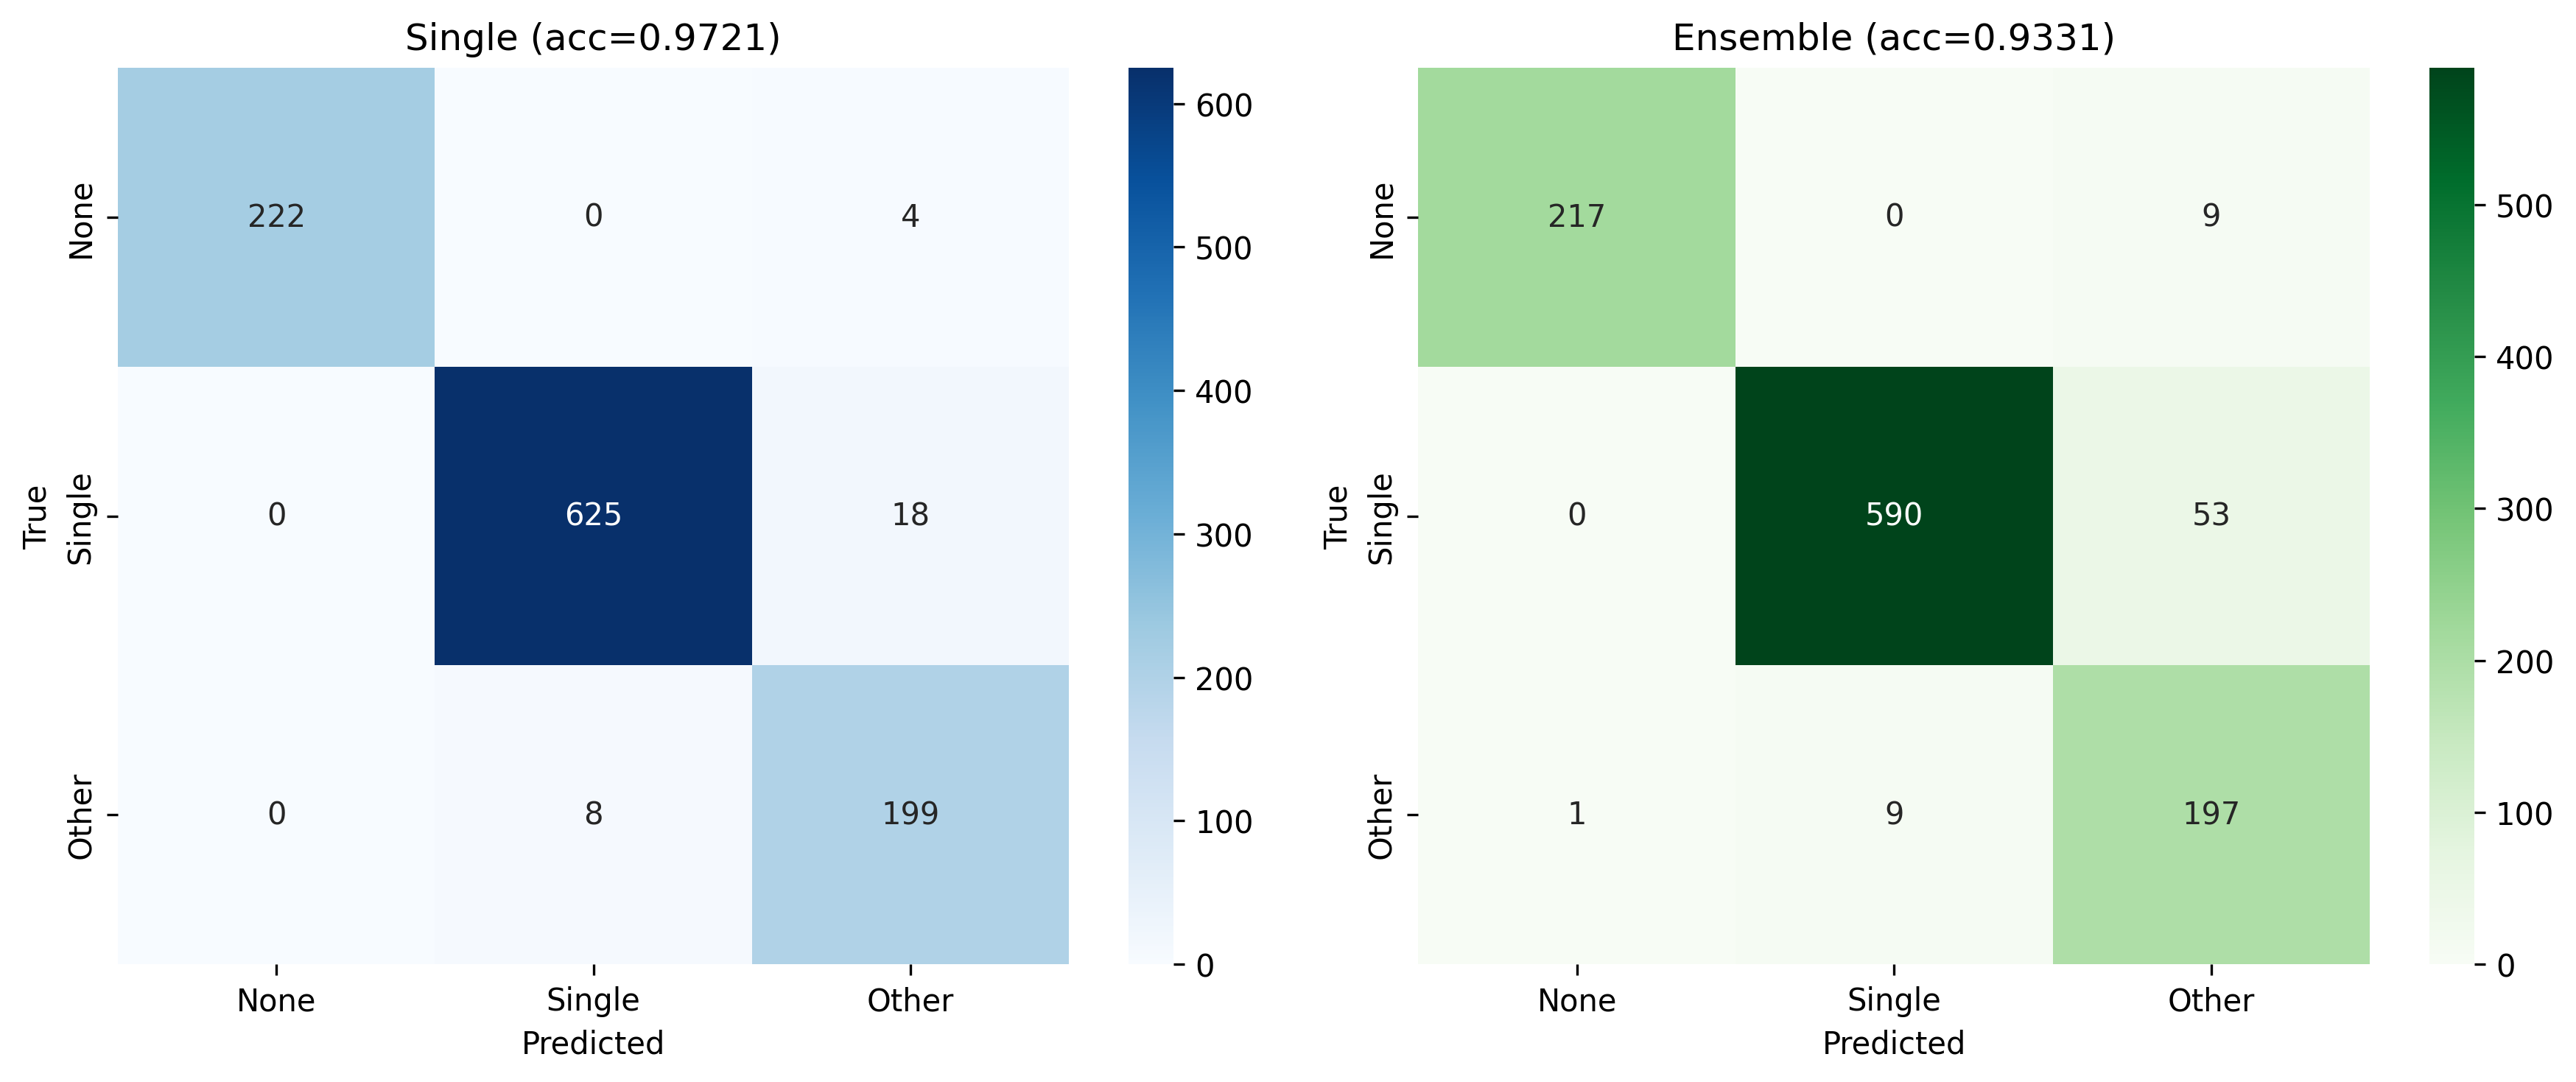


→ Ensemble doesn't help (-3.9%). Use single model.


In [49]:
print("=" * 60)
print("STEP 3: Ensemble Comparison")
print("=" * 60)

_, single_acc, single_preds, single_labels, single_probs = eval_model(
    model, test_loader, criterion, device
)

@torch.no_grad()
def ensemble_predict(models, loader, device):
    all_probs, all_labels = [], []
    for imgs, labels in loader:
        imgs = imgs.to(device)
        batch_probs = []
        for m in models:
            m.eval()
            out = m(imgs)
            batch_probs.append(torch.softmax(out, dim=1).cpu().numpy())
        all_probs.extend(np.mean(batch_probs, axis=0))
        all_labels.extend(labels.numpy())
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_preds = all_probs.argmax(axis=1)
    return (all_preds == all_labels).mean(), all_preds, all_labels, all_probs

ensemble_acc, ensemble_preds, ensemble_labels, ensemble_probs = ensemble_predict(
    fold_models, test_loader, device
)

print(f"Single best model: {single_acc:.4f}")
print(f"Ensemble (5 models): {ensemble_acc:.4f}")
print(f"Improvement: {ensemble_acc - single_acc:+.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=300)

cm_s = confusion_matrix(single_labels, single_preds)
sns.heatmap(cm_s, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['None', 'Single', 'Other'],
            yticklabels=['None', 'Single', 'Other'])
axes[0].set_title(f'Single (acc={single_acc:.4f})')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

cm_e = confusion_matrix(ensemble_labels, ensemble_preds)
sns.heatmap(cm_e, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['None', 'Single', 'Other'],
            yticklabels=['None', 'Single', 'Other'])
axes[1].set_title(f'Ensemble (acc={ensemble_acc:.4f})')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()

improvement = ensemble_acc - single_acc
if improvement > 0.02:
    print(f"\n→ Ensemble gives {improvement:.1%} improvement. USE ENSEMBLE.")
    use_ensemble = True
elif improvement > 0:
    print(f"\n→ Small improvement ({improvement:.1%}). Ensemble recommended.")
    use_ensemble = True
else:
    print(f"\n→ Ensemble doesn't help ({improvement:+.1%}). Use single model.")
    use_ensemble = False

## 8) Uncertainty estimation

STEP 4: Uncertainty Estimation
Samples analyzed: 1076
        confidence  pred_entropy  disagreement  mutual_info
count  1076.000000   1076.000000   1076.000000  1076.000000
mean      0.596958      0.862904      0.247169     0.176495
std       0.110262      0.167953      0.074641     0.076979
min       0.358444      0.141726      0.018682     0.005131
25%       0.526744      0.810101      0.213603     0.133769
50%       0.577857      0.896030      0.247328     0.163632
75%       0.627678      0.962857      0.279027     0.199371
max       0.972880      1.095691      0.430246     0.489573


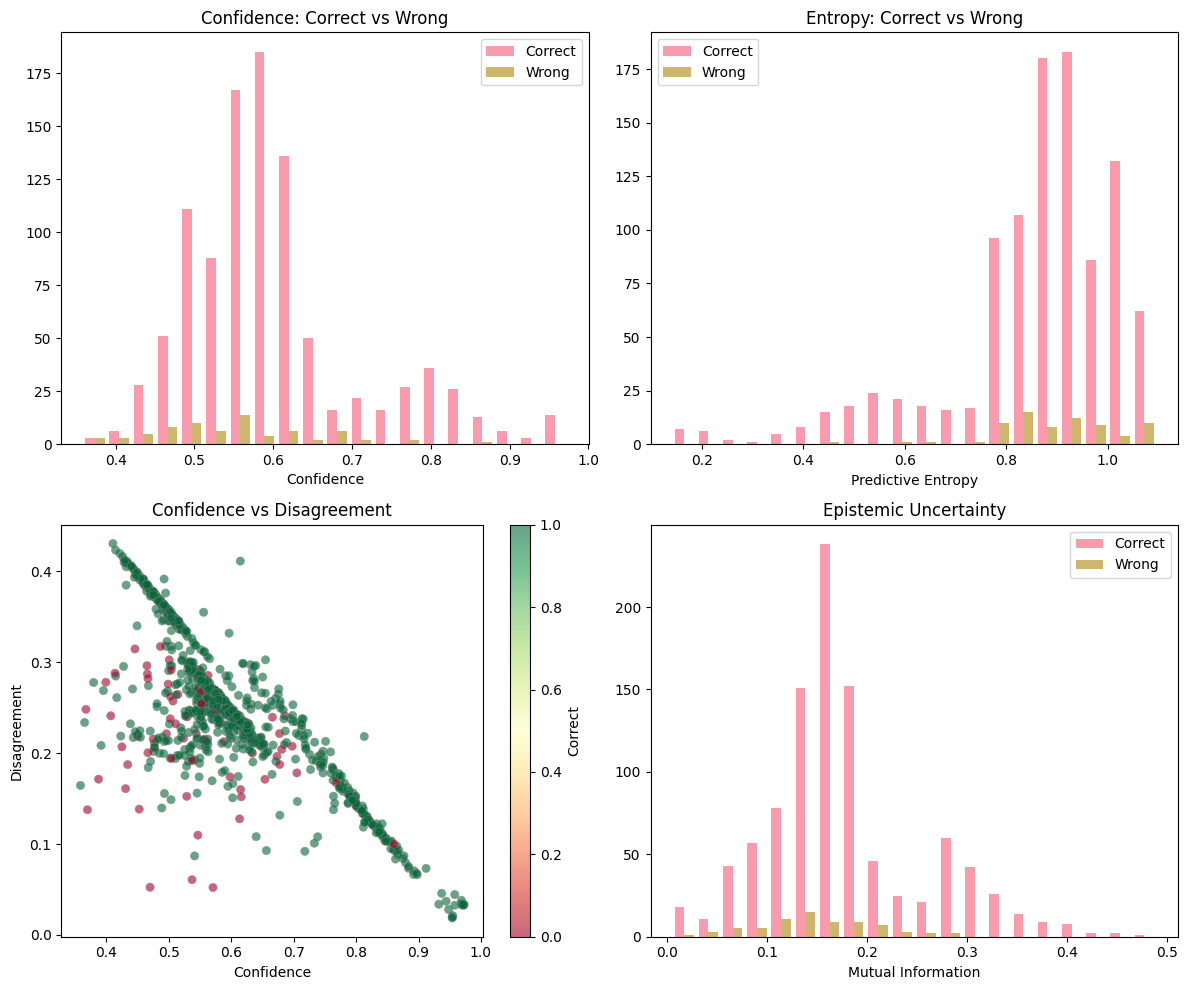


Uncertain samples: 1021/1076 (94.9%)
Accuracy on CERTAIN: 0.9818
Accuracy on UNCERTAIN: 0.9305


In [23]:
print("=" * 60)
print("STEP 4: Uncertainty Estimation")
print("=" * 60)

@torch.no_grad()
def get_uncertainty(models, loader, device):
    results = []
    for imgs, labels in loader:
        imgs = imgs.to(device)
        batch_size = imgs.size(0)
        model_probs = []
        for m in models:
            m.eval()
            out = m(imgs)
            probs = torch.softmax(out, dim=1).cpu().numpy()
            model_probs.append(probs)
        model_probs = np.array(model_probs)

        for i in range(batch_size):
            sample_probs = model_probs[:, i, :]
            avg_prob = sample_probs.mean(axis=0)
            pred_class = avg_prob.argmax()
            confidence = avg_prob.max()
            pred_entropy = -np.sum(avg_prob * np.log(avg_prob + 1e-10))
            disagreement = sample_probs[:, pred_class].std()
            per_model_entropy = -np.sum(
                sample_probs * np.log(sample_probs + 1e-10), axis=1
            )
            mutual_info = pred_entropy - per_model_entropy.mean()

            results.append({
                'true_label': int(labels[i]),
                'pred_label': int(pred_class),
                'confidence': float(confidence),
                'pred_entropy': float(pred_entropy),
                'disagreement': float(disagreement),
                'mutual_info': float(mutual_info),
                'correct': int(pred_class == labels[i]),
            })
    return pd.DataFrame(results)

uncertainty_df = get_uncertainty(fold_models, test_loader, device)
print(f"Samples analyzed: {len(uncertainty_df)}")
print(uncertainty_df[['confidence', 'pred_entropy', 'disagreement', 'mutual_info']].describe())

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].hist(
    [uncertainty_df[uncertainty_df['correct'] == 1]['confidence'],
     uncertainty_df[uncertainty_df['correct'] == 0]['confidence']],
    bins=20, label=['Correct', 'Wrong'], alpha=0.7, stacked=False
)
axes[0, 0].set_xlabel('Confidence')
axes[0, 0].set_title('Confidence: Correct vs Wrong')
axes[0, 0].legend()

axes[0, 1].hist(
    [uncertainty_df[uncertainty_df['correct'] == 1]['pred_entropy'],
     uncertainty_df[uncertainty_df['correct'] == 0]['pred_entropy']],
    bins=20, label=['Correct', 'Wrong'], alpha=0.7, stacked=False
)
axes[0, 1].set_xlabel('Predictive Entropy')
axes[0, 1].set_title('Entropy: Correct vs Wrong')
axes[0, 1].legend()

scatter = axes[1, 0].scatter(
    uncertainty_df['confidence'],
    uncertainty_df['disagreement'],
    c=uncertainty_df['correct'],
    cmap='RdYlGn', alpha=0.6, edgecolors='gray', linewidth=0.5
)
axes[1, 0].set_xlabel('Confidence')
axes[1, 0].set_ylabel('Disagreement')
axes[1, 0].set_title('Confidence vs Disagreement')
plt.colorbar(scatter, ax=axes[1, 0], label='Correct')

axes[1, 1].hist(
    [uncertainty_df[uncertainty_df['correct'] == 1]['mutual_info'],
     uncertainty_df[uncertainty_df['correct'] == 0]['mutual_info']],
    bins=20, label=['Correct', 'Wrong'], alpha=0.7, stacked=False
)
axes[1, 1].set_xlabel('Mutual Information')
axes[1, 1].set_title('Epistemic Uncertainty')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

ENTROPY_THRESHOLD = 0.5
uncertain_mask = uncertainty_df['pred_entropy'] > ENTROPY_THRESHOLD
n_uncertain = uncertain_mask.sum()
n_total = len(uncertainty_df)
print(f"\nUncertain samples: {n_uncertain}/{n_total} ({100*n_uncertain/n_total:.1f}%)")
if (~uncertain_mask).sum() > 0:
    print(f"Accuracy on CERTAIN: {uncertainty_df[~uncertain_mask]['correct'].mean():.4f}")
if uncertain_mask.sum() > 0:
    print(f"Accuracy on UNCERTAIN: {uncertainty_df[uncertain_mask]['correct'].mean():.4f}")

## 9) Ensemble ROC curve

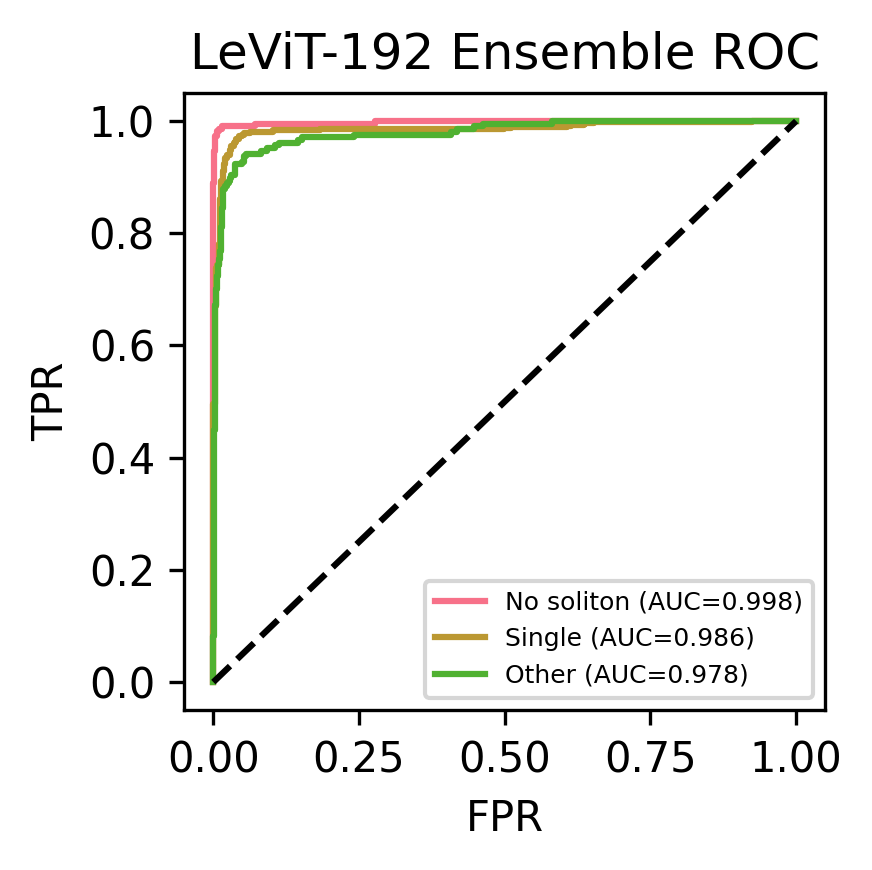

In [62]:
final_probs = ensemble_probs
final_preds = ensemble_preds
final_labels = ensemble_labels
method = "Ensemble"

y_true_bin = label_binarize(final_labels, classes=[0, 1, 2])

plt.figure(figsize=(3, 3), dpi=300)
for i, name in enumerate(['No soliton', 'Single', 'Other']):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], final_probs[:, i])
    auc = roc_auc_score(y_true_bin[:, i], final_probs[:, i])
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title(f'LeViT-192 {method} ROC')
plt.legend(fontsize=6)
plt.tight_layout()
plt.show()

## 10) Final summary

In [26]:
print("=" * 60)
print("FINAL SUMMARY")
print("=" * 60)
print(f"Model:              levit_128 (1ch + adapter)")
print(f"Baseline accuracy:  {single_acc:.4f}")
print(f"CV mean accuracy:   {np.mean(accs):.4f} ± {np.std(accs):.4f}")
print(f"Ensemble accuracy:  {ensemble_acc:.4f}")
print(f"Using:              {'Ensemble' if use_ensemble else 'Single'}")
print(f"Uncertain samples:  {n_uncertain}/{n_total}")

FINAL SUMMARY
Model:              levit_128 (1ch + adapter)
Baseline accuracy:  0.9721
CV mean accuracy:   0.8406 ± 0.0961
Ensemble accuracy:  0.9331
Using:              Single
Uncertain samples:  1021/1076
